# Reinforcement Learning — демонстрационный ноутбук к лекции

Ноутбук ведёт **лектор**, студенты смотрят. Порядок ячеек совпадает с порядком блоков лекции.

| Часть | Блок лекции | Что показываем |
|---|---|---|
| 1 | Блок 3 | Value Iteration на обрыве: ценность растекается волной от цели |
| 2 | Блок 3 | Три ручки: $\gamma$, штраф за шаг, скользкий пол |
| 3 | Блок 4 | Q-learning на той же карте, рядом с ответом из части 1 |
| 4 | Блок 4 | Что бывает без исследования |
| 5 | Блок 5 | LunarLander: DQN, три чекпоинта, график |
| 6 | Блок 5 | Q-значения поверх видео + «зависание» |

**Важно:** часть 5 требует обученных весов. Обучение запускается заранее (`TRAIN = True`), на лекции только загружаем чекпоинты. Подробности — в самой части 5.

In [1]:
# --- Colab: раскомментировать при первом запуске ---------------------------
!pip -q install swig
!pip -q install "gymnasium[box2d]" moviepy
# ---------------------------------------------------------------------------
# Части 1-4 работают на голых numpy + matplotlib, ничего ставить не нужно.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
from IPython.display import HTML, display

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 45.2 MB/s eta 0:00:00


---
## Часть 1. Мир известен: Value Iteration

Карта — классический **обрыв** (cliff walking). Старт слева внизу, цель справа внизу,
между ними вдоль нижнего края тянется пропасть.

Есть два маршрута:
* **вдоль края** — короткий, но одно неверное движение и агент внизу;
* **через верх** — длиннее на несколько шагов, зато безопасный.

Какой из них окажется оптимальным — зависит от настроек, и это ровно то, что мы будем крутить.

Обозначения на карте: `S` старт, `G` цель, `L` пропасть, `#` стена, `.` свободная клетка.

In [2]:
CLIFF = [
    "............",
    "............",
    "............",
    "............",
    "SLLLLLLLLLLG",
]

ARROWS = {0: "\u2191", 1: "\u2192", 2: "\u2193", 3: "\u2190"}   # up right down left


class GridWorld:
    '''Сетчатый мир с полностью известной динамикой.

    Действия: 0 вверх, 1 вправо, 2 вниз, 3 влево.
    slip -- вероятность соскользнуть: агент с вероятностью (1 - slip) идёт куда хотел,
    и с вероятностью slip/2 в каждую из двух перпендикулярных сторон.
    Упереться в стену или в границу = остаться на месте (и всё равно заплатить за шаг).
    '''

    DELTAS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    def __init__(self, layout, step_reward=-1.0, goal_reward=10.0,
                 lava_reward=-100.0, slip=0.0):
        self.grid = np.array([list(row) for row in layout])
        self.n_rows, self.n_cols = self.grid.shape
        self.nS = self.n_rows * self.n_cols
        self.nA = 4

        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.lava_reward = lava_reward
        self.slip = slip

        self.walls = self.grid == "#"
        self.terminal = (self.grid == "L") | (self.grid == "G")
        r0, c0 = np.argwhere(self.grid == "S")[0]
        self.start_state = int(r0 * self.n_cols + c0)

        self._build_model()

    # --- модель среды ------------------------------------------------------
    def _reward_of(self, r, c):
        ch = self.grid[r, c]
        if ch == "G":
            return self.goal_reward
        if ch == "L":
            return self.lava_reward
        return self.step_reward

    def _move(self, r, c, a):
        dr, dc = self.DELTAS[a]
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.n_rows and 0 <= nc < self.n_cols):
            return r, c
        if self.walls[nr, nc]:
            return r, c
        return nr, nc

    def _build_model(self):
        '''P[s, a, s'] -- вероятности переходов, R[s, a] -- ожидаемая награда.'''
        self.P = np.zeros((self.nS, self.nA, self.nS))
        self.R = np.zeros((self.nS, self.nA))

        for s in range(self.nS):
            r, c = divmod(s, self.n_cols)
            # стены и терминальные состояния делаем поглощающими с нулевой наградой
            if self.walls[r, c] or self.terminal[r, c]:
                self.P[s, :, s] = 1.0
                continue
            for a in range(self.nA):
                outcomes = [(a, 1.0 - self.slip),
                            ((a - 1) % 4, self.slip / 2),
                            ((a + 1) % 4, self.slip / 2)]
                for a_real, p in outcomes:
                    if p == 0.0:
                        continue
                    nr, nc = self._move(r, c, a_real)
                    self.P[s, a, nr * self.n_cols + nc] += p
                    self.R[s, a] += p * self._reward_of(nr, nc)

    # --- взаимодействие для model-free части --------------------------------
    def step(self, s, a, rng):
        s2 = int(rng.choice(self.nS, p=self.P[s, a]))
        r, c = divmod(s2, self.n_cols)
        return s2, self._reward_of(r, c), bool(self.terminal[r, c])


env = GridWorld(CLIFF)
print(f"клеток: {env.nS}, действий: {env.nA}, старт в состоянии {env.start_state}")

клеток: 60, действий: 4, старт в состоянии 48


### Value Iteration

Правило Беллмана, применённое по кругу:

$$V(s) \leftarrow \max_a \Big[\, R(s,a) + \gamma \sum_{s'} P(s'\!\mid\! s,a)\, V(s') \,\Big]$$

Стартуем с нулей везде. Ниже — по одному снимку карты ценностей на каждую итерацию.

In [3]:
def value_iteration(env, gamma=0.95, n_iters=60):
    '''Возвращает историю V по итерациям (для анимации).'''
    V = np.zeros(env.nS)
    history = [V.copy()]
    for _ in range(n_iters):
        Q = env.R + gamma * (env.P @ V)      # (nS, nA)
        V = Q.max(axis=1)
        history.append(V.copy())
    return history


def greedy_policy(env, V, gamma):
    Q = env.R + gamma * (env.P @ V)
    return Q.argmax(axis=1)


def draw(env, V, ax, policy=None, title="", vmin=None, vmax=None,
         mask=None, show_values=False):
    '''Рисует тепловую карту ценностей + стрелки политики.

    mask -- булев массив (nS,), True = клетку не показываем (напр. агент там не был).
    '''
    Vg = V.reshape(env.n_rows, env.n_cols).astype(float)
    hidden = env.walls.copy()
    if mask is not None:
        hidden = hidden | mask.reshape(env.n_rows, env.n_cols)

    ax.imshow(np.ma.array(Vg, mask=hidden), cmap="viridis", vmin=vmin, vmax=vmax)

    for r in range(env.n_rows):
        for c in range(env.n_cols):
            ch = env.grid[r, c]
            if ch == "L":
                ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1,
                                           color="#c0392b", zorder=3))
            elif ch == "G":
                ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1,
                                           color="#27ae60", zorder=3))
            elif ch == "#":
                ax.add_patch(plt.Rectangle((c - .5, r - .5), 1, 1,
                                           color="#7f8c8d", zorder=3))
            elif ch == "S":
                ax.text(c, r, "S", ha="center", va="center",
                        color="w", fontweight="bold", zorder=5)

            if hidden[r, c] or env.terminal[r, c]:
                continue
            s = r * env.n_cols + c
            if policy is not None and ch != "S":
                ax.text(c, r, ARROWS[policy[s]], ha="center", va="center",
                        color="w", fontsize=11, zorder=4)
            if show_values:
                ax.text(c, r + .32, f"{Vg[r, c]:.0f}", ha="center", va="center",
                        color="w", fontsize=6, zorder=4)

    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=9)

Запускаем и смотрим анимацию. У плеера снизу есть ползунок — **им и работаем на лекции**:
удобно останавливаться на 1-й, 3-й, 8-й итерации и спрашивать, докуда волна уже дошла.

In [4]:
GAMMA = 0.95
history = value_iteration(env, gamma=GAMMA, n_iters=40)
vmin, vmax = -30, env.goal_reward

fig, ax = plt.subplots(figsize=(6.2, 3.0))

def frame(i):
    ax.clear()
    V = history[i]
    pol = greedy_policy(env, V, GAMMA) if i > 0 else None
    draw(env, V, ax, policy=pol, title=f"Value Iteration, итерация {i}",
         vmin=vmin, vmax=vmax)

anim = animation.FuncAnimation(fig, frame, frames=len(history), interval=350)
plt.close(fig)
HTML(anim.to_jshtml())

---
## Часть 2. Три ручки

Одна и та же карта, один и тот же алгоритм — меняем только настройки.
Числа под картинками подобраны так, чтобы политика менялась заметно; можно править прямо на лекции.

* **$\gamma$** — далеко ли агент смотрит вперёд;
* **штраф за шаг** — сколько стоит время;
* **slip** — вероятность соскользнуть вбок.

Ключевая мысль, которую стоит проговорить: первые две ручки дают *похожий* результат,
но по разным причинам. При маленьком $\gamma$ будущее агенту **не видно**;
при большом штрафе оно ему **дорого стоит**.

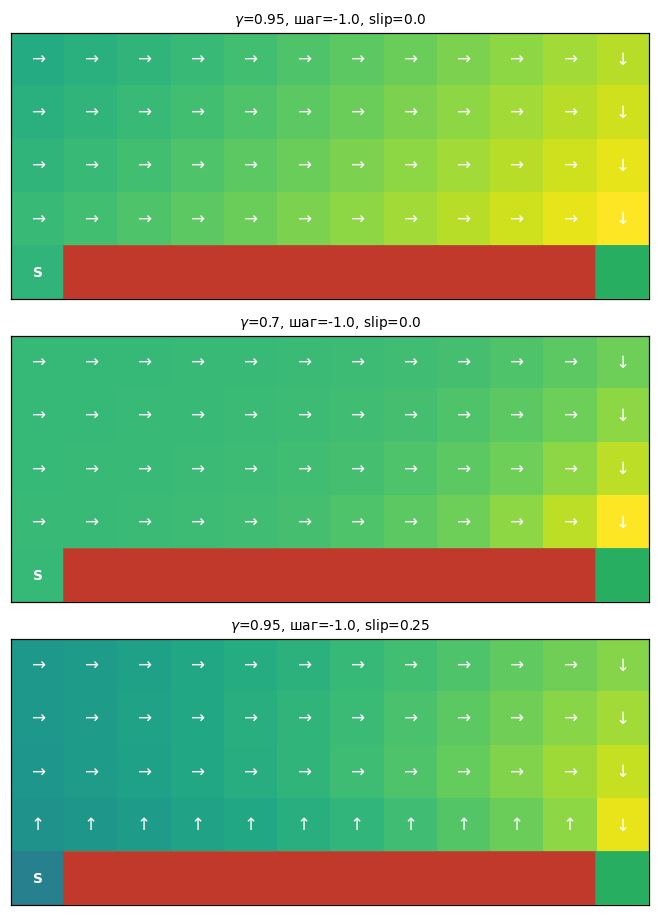

In [5]:
def show_setting(gamma=0.95, step_reward=-1.0, slip=0.0, ax=None, n_iters=200):
    e = GridWorld(CLIFF, step_reward=step_reward, slip=slip)
    V = value_iteration(e, gamma=gamma, n_iters=n_iters)[-1]
    pol = greedy_policy(e, V, gamma)
    title = f"$\\gamma$={gamma}, шаг={step_reward}, slip={slip}"
    draw(e, V, ax, policy=pol, title=title, vmin=-30, vmax=e.goal_reward)
    return V, pol


fig, axes = plt.subplots(3, 1, figsize=(6.2, 8.4))
show_setting(gamma=0.95, step_reward=-1.0, slip=0.0,  ax=axes[0])  # базовый случай
show_setting(gamma=0.70, step_reward=-1.0, slip=0.0,  ax=axes[1])  # близорукий агент
show_setting(gamma=0.95, step_reward=-1.0, slip=0.25, ax=axes[2])  # скользкий пол
plt.tight_layout()
plt.show()

Ползунки для живой игры (в Colab работает из коробки; если ipywidgets не поднялись —
просто правьте числа в ячейке выше и перезапускайте, это доли секунды).

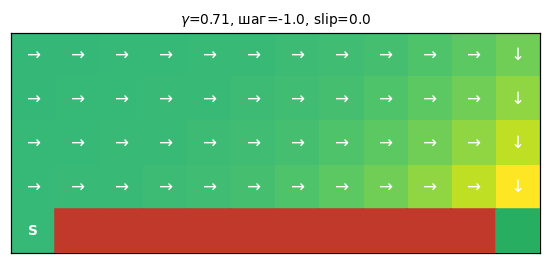

In [6]:
try:
    from ipywidgets import interact, FloatSlider

    @interact(gamma=FloatSlider(0.95, min=0.5, max=0.999, step=0.005, readout_format=".3f"),
              step_reward=FloatSlider(-1.0, min=-10.0, max=0.0, step=0.5),
              slip=FloatSlider(0.0, min=0.0, max=0.5, step=0.05))
    def _play(gamma, step_reward, slip):
        fig, ax = plt.subplots(figsize=(6.2, 2.9))
        show_setting(gamma, step_reward, slip, ax=ax)
        plt.show()
except ImportError:
    print("ipywidgets недоступны — правьте параметры в ячейке выше вручную")

---
## Часть 3. Мир неизвестен: Q-learning

Теперь агент не имеет доступа ни к `P`, ни к `R`. Он просто ходит и после каждого шага
подвигает свою оценку в сторону увиденного:

$$Q(s,a) \;\leftarrow\; Q(s,a) + \alpha\big[\underbrace{r + \gamma\max_{a'}Q(s',a')}_{\text{что увидели}} - \underbrace{Q(s,a)}_{\text{что думали}}\big]$$

Показываем **три панели рядом**:

1. ответ из части 1 (мир известен) — эталон, он не меняется;
2. текущая оценка агента $\max_a Q(s,a)$;
3. счётчик посещений — где агент вообще бывал.

Третья панель тут главная: по ней видно, что агент выучивает не всю карту,
а только окрестность тех маршрутов, которыми ходил.

In [7]:
def q_learning(env, gamma=0.95, alpha=0.5, eps=0.1,
               n_episodes=400, max_steps=200, snapshot_every=5, seed=0):
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.nS, env.nA))
    visits = np.zeros(env.nS)
    snapshots, returns = [], []

    for ep in range(n_episodes):
        s, total, disc = env.start_state, 0.0, 1.0
        for _ in range(max_steps):
            if rng.random() < eps:
                a = int(rng.integers(env.nA))
            else:
                a = int(np.argmax(Q[s]))
            s2, r, done = env.step(s, a, rng)
            target = r if done else r + gamma * Q[s2].max()
            Q[s, a] += alpha * (target - Q[s, a])
            visits[s] += 1
            total += disc * r
            disc *= gamma
            s = s2
            if done:
                break
        returns.append(total)
        if ep % snapshot_every == 0:
            snapshots.append((ep, Q.copy(), visits.copy()))
    return Q, snapshots, returns


env = GridWorld(CLIFF)
V_star = value_iteration(env, gamma=GAMMA, n_iters=200)[-1]
pi_star = greedy_policy(env, V_star, GAMMA)

Q, snaps, returns = q_learning(env, gamma=GAMMA, n_episodes=400)
print(f"снимков: {len(snaps)}")

снимков: 80


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(6.2, 8.4))

def frame(i):
    ep, Qi, vis = snaps[i]
    unseen = vis == 0

    for ax in axes:
        ax.clear()

    draw(env, V_star, axes[0], policy=pi_star,
         title="Мир известен: эталон", vmin=-30, vmax=env.goal_reward)

    draw(env, Qi.max(axis=1), axes[1], policy=Qi.argmax(axis=1), mask=unseen,
         title=f"Q-learning, эпизод {ep}", vmin=-30, vmax=env.goal_reward)

    visg = np.ma.array(np.log1p(vis).reshape(env.n_rows, env.n_cols), mask=env.walls)
    axes[2].imshow(visg, cmap="magma")
    axes[2].set_xticks([]); axes[2].set_yticks([])
    axes[2].set_title("Где агент вообще был (log-шкала)", fontsize=9)

anim = animation.FuncAnimation(fig, frame, frames=len(snaps), interval=180)
plt.close(fig)
HTML(anim.to_jshtml())

График отдачи за эпизод. Провалы вниз — это эпизоды, в которых агент свалился в пропасть;
их частота падает, но полностью не исчезает — виноват $\varepsilon$.

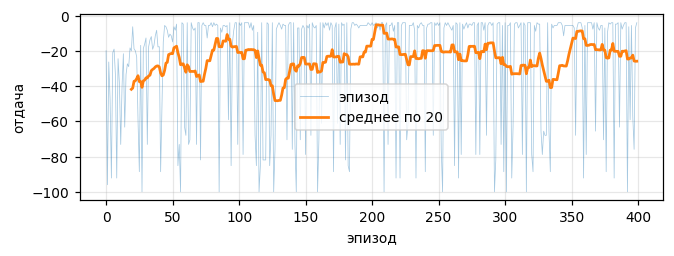

In [9]:
def rolling(x, k=20):
    x = np.asarray(x, dtype=float)
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(figsize=(6.2, 2.4))
ax.plot(returns, lw=.5, alpha=.4, label="эпизод")
ax.plot(np.arange(len(rolling(returns))) + 19, rolling(returns), lw=1.8,
        label="среднее по 20")
ax.set_xlabel("эпизод"); ax.set_ylabel("отдача")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## Часть 4. Что бывает без исследования

Один и тот же алгоритм, разное $\varepsilon$. Серым закрашены клетки, куда агент ни разу не заглянул.

* $\varepsilon = 0$ — агент цепляется за первый найденный маршрут и не проверяет альтернативы;
* $\varepsilon = 0.1$ — рабочий режим;
* $\varepsilon = 0.5$ — половину времени агент творит ерунду: карту знает отлично, а отдача низкая.

Последний случай стоит подчеркнуть: **выучить хорошую $Q$ и хорошо себя вести — это разные вещи.**

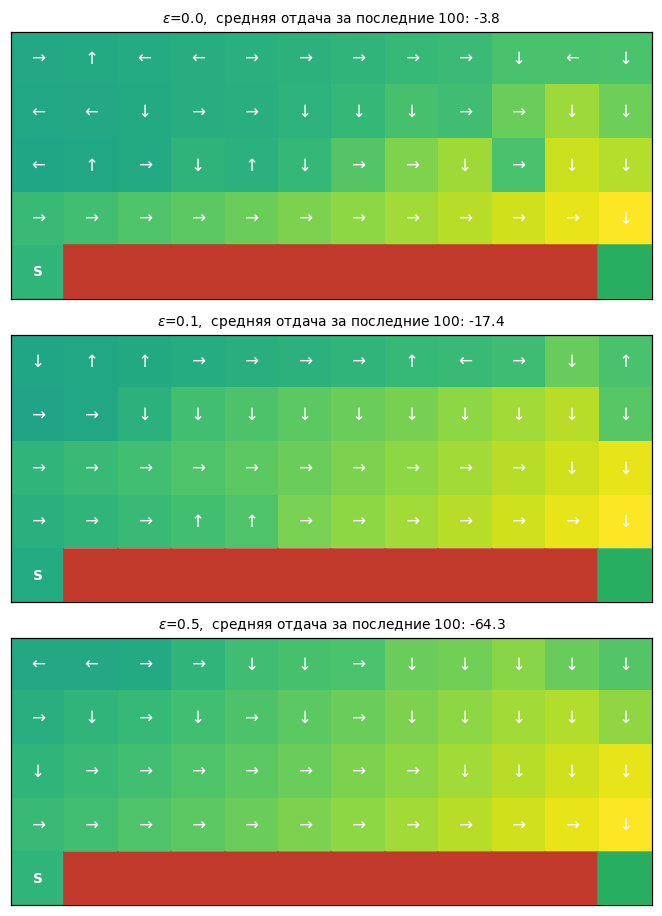

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(6.2, 8.4))
for ax, eps in zip(axes, [0.0, 0.1, 0.5]):
    e = GridWorld(CLIFF)
    _, snaps_e, ret_e = q_learning(e, gamma=GAMMA, eps=eps, n_episodes=400, seed=1)
    _, Qlast, vis = snaps_e[-1]
    draw(e, Qlast.max(1), ax, policy=Qlast.argmax(1), mask=(vis == 0),
         title=f"$\\varepsilon$={eps},  средняя отдача за последние 100: {np.mean(ret_e[-100:]):.1f}",
         vmin=-30, vmax=e.goal_reward)
plt.tight_layout(); plt.show()

---
## Часть 5. LunarLander + DQN

Здесь таблица заканчивается: состояние — восемь вещественных чисел.
Заменяем её сетью `8 -> 128 -> 128 -> 4`.

> ### Что нужно сделать ЗАРАНЕЕ
>
> Обучение занимает от четверти часа до нескольких часов в зависимости от машины
> (порог берётся обычно на 400–600-м эпизоде). **На лекции его не запускаем.**
>
> 1. Дома выставить `TRAIN = True` и прогнать ячейку обучения.
> 2. Убедиться, что в `checkpoints/` лежат файлы `dqn_ep000.pt`, `dqn_ep100.pt`, … и `scores.npy`.
> 3. Прогнать ячейки записи видео, проверить, что ролики открываются.
> 4. На лекции — `TRAIN = False`, всё грузится с диска за секунды.
>
> Папку `checkpoints/` держать рядом с ноутбуком (в Colab — закинуть на Google Drive
> и примонтировать, иначе она умрёт вместе с сессией).

In [11]:
import os, base64, random
from collections import deque

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch
import torch.nn as nn
import torch.nn.functional as F

ENV_ID = "LunarLander-v3"       # ВНИМАНИЕ: в Gymnasium 1.0 версия сменилась с v2 на v3
CKPT_DIR = "checkpoints"
VIDEO_DIR = "videos"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("устройство:", DEVICE)

probe = gym.make(ENV_ID)
print("состояние:", probe.observation_space)
print("действия :", probe.action_space)
probe.close()

ACTION_NAMES = ["ничего", "левый", "главный", "правый"]


def show_video(path, width=460):
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return HTML(f'<video width="{width}" controls loop>'
                f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>')

устройство: cpu
состояние: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
действия : Discrete(4)


### 5.1 Случайная политика

Первое, что видят студенты (эту же ячейку удобно показать ещё в начале лекции, в блоке 1).

In [12]:
def record_random(prefix="random", seed=0):
    e = gym.make(ENV_ID, render_mode="rgb_array")
    e = RecordVideo(e, video_folder=VIDEO_DIR, name_prefix=prefix,
                    episode_trigger=lambda i: i == 0, disable_logger=True)
    obs, _ = e.reset(seed=seed)
    total, done = 0.0, False
    while not done:
        obs, r, term, trunc, _ = e.step(e.action_space.sample())
        total += r
        done = term or trunc
    e.close()
    return total, os.path.join(VIDEO_DIR, f"{prefix}-episode-0.mp4")


score, path = record_random()
print(f"счёт случайной политики: {score:.1f}")
show_video(path)

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.13/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


счёт случайной политики: -79.0


### 5.2 Агент

Три заплатки из лекции видны прямо в коде:

* `ReplayBuffer` — учимся не на последних кадрах, а на случайной выборке из прошлого;
* `self.target` — вторая, медленно догоняющая копия сети, чтобы цель не убегала;
* `eps` в `act()` — иногда нарочно делаем не лучшее действие.

In [13]:
class QNet(nn.Module):
    def __init__(self, n_obs=8, n_act=4, hidden=128):
        super().__init__()
        self.f = nn.Sequential(
            nn.Linear(n_obs, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_act),
        )

    def forward(self, x):
        return self.f(x)


class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buf = deque(maxlen=capacity)

    def add(self, *transition):
        self.buf.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return (torch.tensor(s, dtype=torch.float32, device=DEVICE),
                torch.tensor(a, dtype=torch.int64, device=DEVICE),
                torch.tensor(r, dtype=torch.float32, device=DEVICE),
                torch.tensor(s2, dtype=torch.float32, device=DEVICE),
                torch.tensor(d, dtype=torch.float32, device=DEVICE))

    def __len__(self):
        return len(self.buf)


class DQNAgent:
    def __init__(self, n_obs=8, n_act=4, lr=5e-4, gamma=0.99,
                 batch_size=64, tau=1e-3, learn_every=4):
        self.online = QNet(n_obs, n_act).to(DEVICE)
        self.target = QNet(n_obs, n_act).to(DEVICE)
        self.target.load_state_dict(self.online.state_dict())
        self.opt = torch.optim.Adam(self.online.parameters(), lr=lr)

        self.memory = ReplayBuffer()
        self.gamma, self.batch_size = gamma, batch_size
        self.tau, self.learn_every = tau, learn_every
        self.n_act, self._t = n_act, 0

    @torch.no_grad()
    def q_values(self, state):
        s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return self.online(s).cpu().numpy()[0]

    def act(self, state, eps=0.0):
        if random.random() < eps:
            return random.randrange(self.n_act)
        return int(np.argmax(self.q_values(state)))

    def step(self, s, a, r, s2, done):
        self.memory.add(s, a, r, s2, float(done))
        self._t += 1
        if self._t % self.learn_every == 0 and len(self.memory) >= self.batch_size:
            self._learn()

    def _learn(self):
        s, a, r, s2, d = self.memory.sample(self.batch_size)

        with torch.no_grad():
            # цель считаем замороженной сетью и НЕ дифференцируем по ней
            q_next = self.target(s2).max(dim=1).values
            target = r + self.gamma * q_next * (1 - d)

        q = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)
        loss = F.mse_loss(q, target)

        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

        # мягкое обновление замороженной копии
        for p_t, p_o in zip(self.target.parameters(), self.online.parameters()):
            p_t.data.copy_(self.tau * p_o.data + (1 - self.tau) * p_t.data)

### 5.3 Обучение — ЗАПУСКАТЬ ЗАРАНЕЕ

Чекпоинты сохраняются каждые 100 эпизодов. Именно из них потом делаются ролики
«эпизод 0 / 200 / 500».

In [15]:
TRAIN = True          # <-- дома поставить True, на лекции оставить False
N_EPISODES = 700
MAX_STEPS = 1000
EPS_START, EPS_END, EPS_DECAY = 1.0, 0.01, 0.995
SAVE_EVERY = 100


def train():
    e = gym.make(ENV_ID)
    agent = DQNAgent()
    scores, eps = [], EPS_START

    torch.save(agent.online.state_dict(), f"{CKPT_DIR}/dqn_ep000.pt")  # необученная сеть

    for ep in range(1, N_EPISODES + 1):
        obs, _ = e.reset()
        total = 0.0
        for _ in range(MAX_STEPS):
            a = agent.act(obs, eps)
            obs2, r, term, trunc, _ = e.step(a)
            agent.step(obs, a, r, obs2, term)
            obs, total = obs2, total + r
            if term or trunc:
                break
        scores.append(total)
        eps = max(EPS_END, EPS_DECAY * eps)

        if ep % 20 == 0:
            print(f"эпизод {ep:4d} | среднее за 100: {np.mean(scores[-100:]):7.1f} | eps {eps:.3f}")
        if ep % SAVE_EVERY == 0:
            torch.save(agent.online.state_dict(), f"{CKPT_DIR}/dqn_ep{ep:03d}.pt")
            np.save(f"{CKPT_DIR}/scores.npy", np.array(scores))

    np.save(f"{CKPT_DIR}/scores.npy", np.array(scores))
    e.close()
    return agent, scores


if TRAIN:
    agent, scores = train()
else:
    scores = np.load(f"{CKPT_DIR}/scores.npy")
    print(f"загружено {len(scores)} эпизодов обучения")

эпизод   20 | среднее за 100:  -169.3 | eps 0.905
эпизод   40 | среднее за 100:  -165.4 | eps 0.818
эпизод   60 | среднее за 100:  -174.4 | eps 0.740
эпизод   80 | среднее за 100:  -164.5 | eps 0.670
эпизод  100 | среднее за 100:  -159.5 | eps 0.606
эпизод  120 | среднее за 100:  -149.9 | eps 0.548
эпизод  140 | среднее за 100:  -141.7 | eps 0.496
эпизод  160 | среднее за 100:  -122.7 | eps 0.448
эпизод  180 | среднее за 100:  -111.3 | eps 0.406
эпизод  200 | среднее за 100:   -94.7 | eps 0.367
эпизод  220 | среднее за 100:   -86.0 | eps 0.332
эпизод  240 | среднее за 100:   -83.8 | eps 0.300
эпизод  260 | среднее за 100:   -78.5 | eps 0.272
эпизод  280 | среднее за 100:   -76.7 | eps 0.246
эпизод  300 | среднее за 100:   -70.6 | eps 0.222
эпизод  320 | среднее за 100:   -59.7 | eps 0.201
эпизод  340 | среднее за 100:   -42.4 | eps 0.182
эпизод  360 | среднее за 100:   -34.5 | eps 0.165
эпизод  380 | среднее за 100:   -18.5 | eps 0.149
эпизод  400 | среднее за 100:   -12.4 | eps 0.135


### 5.4 График

Порог 200 — общепринятый критерий «задача решена» (среднее по 100 подряд идущим эпизодам).
На графике хорошо видны три фазы: долгий минус, резкий подъём, шумное плато.

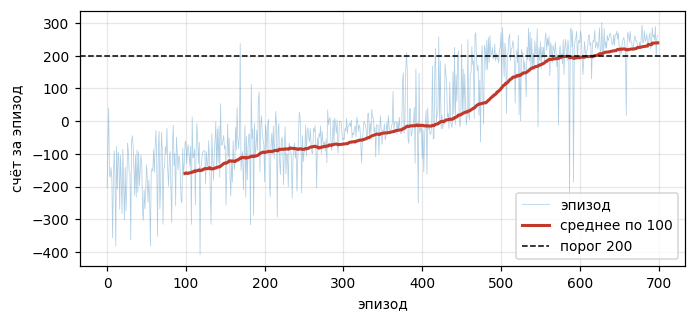

In [16]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(scores, lw=.5, alpha=.35, label="эпизод")
roll = rolling(scores, 100)
ax.plot(np.arange(len(roll)) + 99, roll, lw=2, color="#c0392b", label="среднее по 100")
ax.axhline(200, ls="--", lw=1, color="k", label="порог 200")
ax.set_xlabel("эпизод"); ax.set_ylabel("счёт за эпизод")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.5 Три ролика

Подберите номера чекпоинтов под свой прогон. Ориентир:

* **ep000** — необученная сеть, кувыркается;
* **средний** (обычно 200–300) — тот самый агент, который **научился зависать и не садиться**:
  разбиться стоит $-100$, а главный двигатель — всего $-0.3$ за кадр, так что тянуть время
  выгоднее, чем рисковать. Это лучшая иллюстрация к разговору про награду;
* **последний** — садится.

Если в вашем прогоне зависания не случилось, посмотрите соседние чекпоинты: фаза короткая,
но встречается почти всегда.

In [17]:
def record_policy(ckpt, prefix, seed=0, max_steps=1000):
    agent = DQNAgent()
    agent.online.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    agent.online.eval()

    e = gym.make(ENV_ID, render_mode="rgb_array")
    e = RecordVideo(e, video_folder=VIDEO_DIR, name_prefix=prefix,
                    episode_trigger=lambda i: i == 0, disable_logger=True)
    obs, _ = e.reset(seed=seed)
    total = 0.0
    for _ in range(max_steps):
        obs, r, term, trunc, _ = e.step(agent.act(obs))
        total += r
        if term or trunc:
            break
    e.close()
    return total, os.path.join(VIDEO_DIR, f"{prefix}-episode-0.mp4")


CKPTS = [("dqn_ep000.pt", "до обучения"),
         ("dqn_ep200.pt", "середина обучения"),
         ("dqn_ep700.pt", "обученный агент")]

for fname, label in CKPTS:
    path_ckpt = os.path.join(CKPT_DIR, fname)
    if not os.path.exists(path_ckpt):
        print(f"[пропуск] нет файла {path_ckpt}")
        continue
    sc, vid = record_policy(path_ckpt, prefix=fname.replace(".pt", ""))
    print(f"{label}: счёт {sc:.1f}")
    display(show_video(vid))

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


до обучения: счёт -296.2


середина обучения: счёт -107.6


обученный агент: счёт 283.5


### 5.6 Q-значения поверх видео

Слева кадр, справа четыре столбика — что сеть думает о каждом двигателе прямо сейчас.
Оранжевым подсвечено выбранное действие.

Смотреть стоит на две вещи: как **все четыре столбика ползут вверх** по мере приближения
к площадке (агент понимает, что дела идут хорошо), и как за секунду до касания
резко выигрывает «главный».

In [19]:
def rollout_with_q(ckpt, seed=0, max_steps=600, stride=2):
    agent = DQNAgent()
    agent.online.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    agent.online.eval()

    e = gym.make(ENV_ID, render_mode="rgb_array")
    obs, _ = e.reset(seed=seed)
    frames, qs, acts = [], [], []
    for t in range(max_steps):
        q = agent.q_values(obs)
        a = int(np.argmax(q))
        if t % stride == 0:
            frames.append(e.render()); qs.append(q); acts.append(a)
        obs, r, term, trunc, _ = e.step(a)
        if term or trunc:
            break
    e.close()
    return frames, np.array(qs), acts


def animate_q(frames, qs, acts, out="q_overlay.mp4", fps=15):
    lo, hi = qs.min(), qs.max()
    pad = 0.1 * (hi - lo + 1e-6)

    fig, (ax_v, ax_q) = plt.subplots(
        1, 2, figsize=(8.2, 3.4), gridspec_kw={"width_ratios": [2, 1]})

    def upd(i):
        ax_v.clear(); ax_q.clear()
        ax_v.imshow(frames[i]); ax_v.axis("off")

        colors = ["#95a5a6"] * 4
        colors[acts[i]] = "#e67e22"
        ax_q.barh(range(4), qs[i], color=colors)
        ax_q.set_yticks(range(4)); ax_q.set_yticklabels(ACTION_NAMES)
        ax_q.invert_yaxis()
        ax_q.set_xlim(lo - pad, hi + pad)
        ax_q.axvline(0, color="k", lw=.6)
        ax_q.set_title("Q(s, a)", fontsize=9)

    anim = animation.FuncAnimation(fig, upd, frames=len(frames), interval=1000 // fps)
    plt.close(fig)
    try:
        anim.save(out, fps=fps)
        return show_video(out, width=680)
    except Exception as exc:               # нет ffmpeg -- отдаём встроенный плеер
        print("не удалось сохранить mp4:", exc)
        return HTML(anim.to_jshtml())


BEST = os.path.join(CKPT_DIR, "dqn_ep700.pt")
if os.path.exists(BEST):
    frames, qs, acts = rollout_with_q(BEST, seed=3)
    display(animate_q(frames, qs, acts))
else:
    print(f"нет файла {BEST} -- сначала обучите агента")